In [1]:
import numpy as np

filepath = r"C:\Users\josep\Documents\MRes mini-project 2\Figures\RIN\RIN_second_param_set.cht"

with open(filepath, 'r') as f:
    lines = f.readlines()

# Find the header row ("Xvals, Yvals1 ,") and start reading data on the next line
data_start = None
for i, line in enumerate(lines):
    if line.strip().startswith("Xvals"):
        data_start = i + 1
        break

if data_start is None:
    raise ValueError("Could not find 'Xvals' header in file.")

x_vals, y_vals = [], []
for line in lines[data_start:]:
    line = line.strip()
    if not line:
        continue
    parts = line.split(',')
    if len(parts) < 2:
        continue
    try:
        x_vals.append(float(parts[0]))
        y_vals.append(float(parts[1]))
    except ValueError:
        continue  # skip any malformed/trailing lines

x = np.array(x_vals)  # offset frequency (MHz)
y = np.array(y_vals)  # RIN (dB/Hz)

print(f"Loaded {len(x)} points")
print(f"X range: {x.min():.3f} – {x.max():.3f} MHz")
print(f"Y range: {y.min():.3f} – {y.max():.3f} dB/Hz")

Loaded 3598 points
X range: 27.778 – 99944.600 MHz
Y range: -172.805 – -142.734 dB/Hz


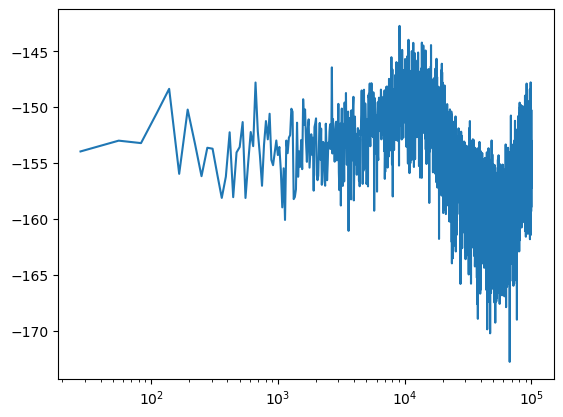

In [5]:
plt.semilogx(x,y)

Loading PICWave field data from 'C:\Users\josep\Documents\MRes mini-project 2\Figures\RIN\9_mA.ascii'...
Start-time cutoff at 100 ns: dropping 832,756 / 83,442,234 samples (1.0%).
Resampling onto a uniform time grid...
Computing RIN PSD (Welch)...


C:\Users\josep\AppData\Local\Temp\ipykernel_10512\256416820.py:163: RuntimeWarning: divide by zero encountered in scalar divide
  fmax_nyquist = 0.5 / (dt_ns * 1e-9)
C:\Users\josep\AppData\Local\Temp\ipykernel_10512\256416820.py:171: RuntimeWarning: divide by zero encountered in log10
  "rin_db": 10 * np.log10(rin_binned),


Log-binning for display...


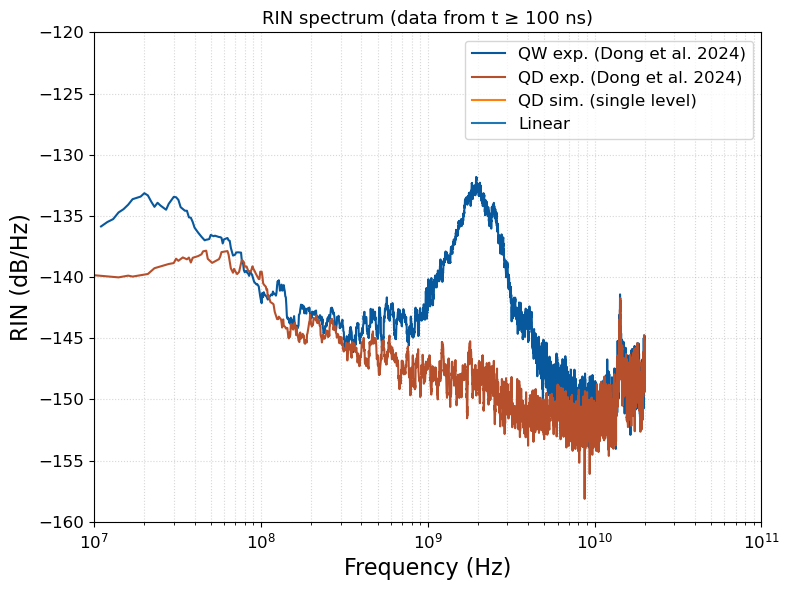

Saved to 'C:\Users\josep\Documents\MRes mini-project 2\Figures\RIN\rin_spectrum_start100ns.png'


In [2]:
# =============================================================================
# RIN spectrum from raw PICWave time-domain data, with a start-time cutoff
# =============================================================================
import os
import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
from scipy.signal import welch

# -----------------------------------------------------------------------------
# 1. USER SETTINGS — edit these
# -----------------------------------------------------------------------------
# One entry per model you want to plot. 'path' = raw PICWave ascii field file.
MODELS = [
    {
        "label": "QD sim. (single level)",
        "path": r"C:\Users\josep\Documents\MRes mini-project 2\Figures\RIN\9_mA.ascii",
        "color": "#ff7f0e",
    },
    # Add a second dict here for the multilevel model, e.g.:
    # {
    #     "label": "QD sim. (multilevel)",
    #     "path": r"C:\Users\josep\Documents\MRes mini-project 2\Figures\RIN\multilevel_phases.ascii",
    #     "color": "#2ca02c",
    # },
]

START_TIME_NS = 100.0    # <-- discard all samples before this time (ns) before computing RIN
FMIN = 1e7               # Hz, plot/analysis lower bound
FMAX = 1e11               # Hz, plot/analysis upper bound (was 1e10, now extended)
NPERSEG_POW2 = 22         # Welch segment length = 2**this (reduced automatically if not enough data)
NOVERLAP_FRAC = 0.5
POINTS_PER_DECADE = 150   # log-bin resolution for display

INCLUDE_EXPERIMENTAL = True
QW_MAT = r"C:\Users\josep\Documents\MRes mini-project 2\Figures\RIN\Fig2b\230215_QW_RIN.mat"
QD_MAT = r"C:\Users\josep\Documents\MRes mini-project 2\Figures\RIN\Fig2b\230301_QD_D3B3_D08_RIN.mat"

OUT_PATH = r"C:\Users\josep\Documents\MRes mini-project 2\Figures\RIN\rin_spectrum_start{:.0f}ns.png".format(START_TIME_NS)

# -----------------------------------------------------------------------------
# 2. Helper functions
# -----------------------------------------------------------------------------
def load_picwave_field(path):
    print(f"Loading PICWave field data from '{path}'...")
    with open(path, "r") as f:
        first_line = f.readline()
    try:
        npoints_expected = int(first_line.split()[0])
    except (IndexError, ValueError):
        npoints_expected = None
        print("Warning: could not parse npoints from first line; continuing anyway.")

    df = pd.read_csv(
        path,
        sep=r"\s+",
        skiprows=2,
        header=None,
        usecols=[0, 1],
        names=["t_ns", "amp"],
        dtype={"t_ns": np.float64, "amp": np.float32},
        engine="c",
    )

    if npoints_expected is not None and len(df) != npoints_expected:
        print(f"Warning: header declared {npoints_expected:,} points, "
              f"read {len(df):,}. Proceeding with what was read.")

    return df["t_ns"].to_numpy(), df["amp"].to_numpy()


def apply_start_time_cutoff(t_ns, amp, start_time_ns):
    """Discard all samples with t_ns < start_time_ns."""
    mask = t_ns >= start_time_ns
    n_dropped = np.size(mask) - np.count_nonzero(mask)
    print(f"Start-time cutoff at {start_time_ns:g} ns: dropping {n_dropped:,} / {len(t_ns):,} samples "
          f"({n_dropped/len(t_ns)*100:.1f}%).")
    if not np.any(mask):
        raise ValueError(f"start_time_ns={start_time_ns} is beyond the last sample "
                          f"(t_ns max = {t_ns.max():g}). No data left.")
    return t_ns[mask], amp[mask]


def resample_uniform(t_ns, amp):
    print("Resampling onto a uniform time grid...")
    dt_ns = np.median(np.diff(t_ns))
    n = len(t_ns)
    t_uniform_ns = t_ns[0] + dt_ns * np.arange(n)
    amp_uniform = np.interp(t_uniform_ns, t_ns, amp).astype(np.float32)
    return t_uniform_ns, amp_uniform, dt_ns


def compute_rin_psd(amp_uniform, dt_ns, nperseg_pow2=22, noverlap_frac=0.5):
    print("Computing RIN PSD (Welch)...")
    dt_ns = 0.00012008

    fs = 1.0 / (dt_ns * 1e-9)  # Hz

    P = amp_uniform.astype(np.float64) ** 2
    P_avg = np.mean(P)
    dP = P - P_avg

    nperseg = min(2 ** nperseg_pow2, len(dP))
    noverlap = int(nperseg * noverlap_frac)

    freq, Pxx = welch(
        dP,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        window="hann",
        detrend=False,
        scaling="density",
        return_onesided=True,
    )

    rin = Pxx / P_avg ** 2  # 1/Hz
    return freq, rin


def log_bin_average(freq, rin, f_min, f_max, points_per_decade=150):
    print("Log-binning for display...")
    mask = (freq >= f_min) & (freq <= f_max) & (freq > 0)
    freq = freq[mask]
    rin = rin[mask]

    n_decades = np.log10(f_max / f_min)
    n_bins = max(int(n_decades * points_per_decade), 10)
    bin_edges = np.logspace(np.log10(f_min), np.log10(f_max), n_bins + 1)

    idx = np.digitize(freq, bin_edges)

    freq_binned, rin_binned = [], []
    for i in range(1, n_bins + 1):
        sel = idx == i
        if np.any(sel):
            freq_binned.append(np.sqrt(bin_edges[i - 1] * bin_edges[i]))  # geometric mean
            rin_binned.append(np.mean(rin[sel]))  # average in linear power

    return np.array(freq_binned), np.array(rin_binned)


def smooth_data(y, span=20):
    return pd.Series(y).rolling(window=span, min_periods=1, center=True).mean().to_numpy()


# -----------------------------------------------------------------------------
# 3. Compute RIN for each model (with the start-time cutoff applied)
# -----------------------------------------------------------------------------
results = []
for m in MODELS:
    if not os.path.exists(m["path"]):
        print(f"Error: file not found: {m['path']}")
        continue

    t_ns, amp = load_picwave_field(m["path"])
    t_ns, amp = apply_start_time_cutoff(t_ns, amp, START_TIME_NS)
    t_ns_u, amp_u, dt_ns = resample_uniform(t_ns, amp)
    freq, rin = compute_rin_psd(amp_u, dt_ns, nperseg_pow2=NPERSEG_POW2, noverlap_frac=NOVERLAP_FRAC)

    # bin a bit beyond FMAX to be safe near the edge, then clip when plotting
    fmax_nyquist = 0.5 / (dt_ns * 1e-9)
    bin_fmax = min(FMAX * 2, fmax_nyquist)
    freq_binned, rin_binned = log_bin_average(freq, rin, FMIN, bin_fmax, points_per_decade=POINTS_PER_DECADE)

    results.append({
        "label": m["label"],
        "color": m["color"],
        "freq": freq_binned,
        "rin_db": 10 * np.log10(rin_binned),
    })

# -----------------------------------------------------------------------------
# 4. Optional experimental overlay (QW / QD)
# -----------------------------------------------------------------------------
exp_traces = []
if INCLUDE_EXPERIMENTAL:
    if os.path.exists(QW_MAT) and os.path.exists(QD_MAT):
        qw_mat = scipy.io.loadmat(QW_MAT)
        qd_mat = scipy.io.loadmat(QD_MAT)
        qw_fr, qw_rin = qw_mat["b"].squeeze(), qw_mat["bb"].squeeze()
        qd_fr, qd_rin = qd_mat["b"].squeeze(), qd_mat["bb"].squeeze()
        exp_traces.append(("QW exp. (Dong et al. 2024)", qw_fr, smooth_data(qw_rin, 20), (8/256, 88/256, 158/256)))
        exp_traces.append(("QD exp. (Dong et al. 2024)", qd_fr, smooth_data(qd_rin, 20), (183/256, 79/256, 43/256)))
    else:
        print("Warning: experimental .mat files not found; skipping overlay.")

# -----------------------------------------------------------------------------
# 5. Plot — RIN spectrum only, extended to 1e11 Hz
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

for label, fr, rin_smooth, color in exp_traces:
    ax.semilogx(fr, rin_smooth, color=color, lw=1.5, label=label)

for r in results:
    ax.semilogx(r["freq"], r["rin_db"], color=r["color"], lw=1.5, label=r["label"])
ax.semilogx(x,y,label='Linear')
ax.set_xlim(FMIN, FMAX)
ax.set_ylim(-160, -120)
ax.set_xlabel("Frequency (Hz)", fontsize=16)
ax.set_ylabel("RIN (dB/Hz)", fontsize=16)
ax.tick_params(axis="both", which="major", labelsize=12)
ax.legend(loc="upper right", frameon=True, fontsize=12)
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.set_title(f"RIN spectrum (data from t ≥ {START_TIME_NS:g} ns)", fontsize=13)

plt.tight_layout()
plt.savefig(OUT_PATH, dpi=300)
plt.show()
print(f"Saved to '{OUT_PATH}'")